Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

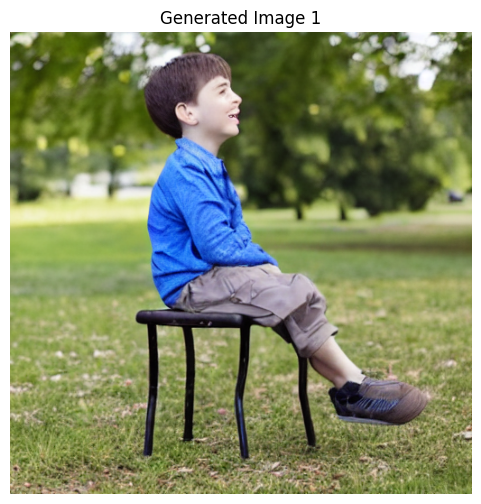

  0%|          | 0/50 [00:00<?, ?it/s]

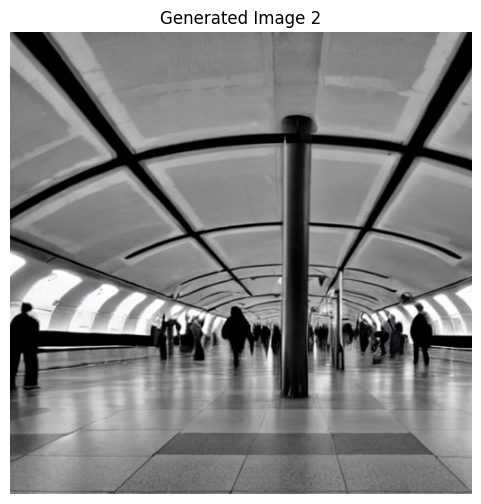

  0%|          | 0/50 [00:00<?, ?it/s]

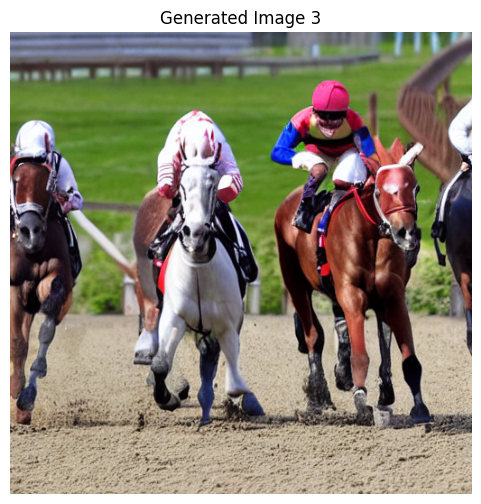

  0%|          | 0/50 [00:00<?, ?it/s]

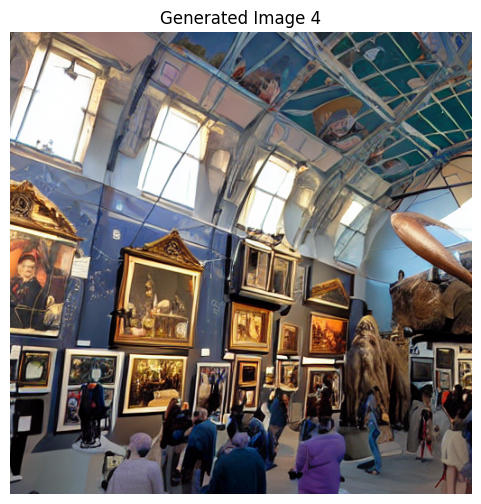

  0%|          | 0/50 [00:00<?, ?it/s]

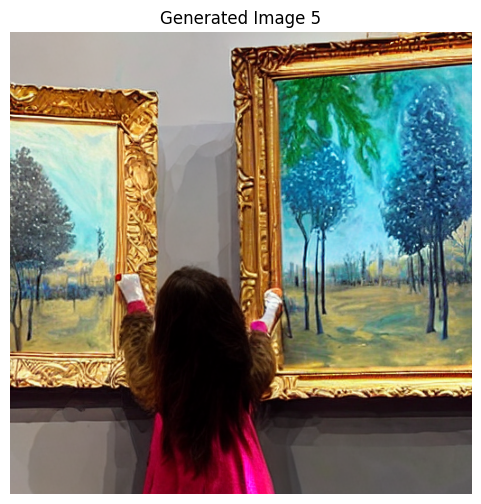

✅ Synthetic dataset generated and displayed successfully!


In [4]:
# Step 1: Install required libraries
!pip install diffusers transformers torch accelerate

# Step 2: Import required libraries
import torch
from diffusers import StableDiffusionPipeline
import os
from PIL import Image
import matplotlib.pyplot as plt

# Step 3: Load pre-trained Stable Diffusion model
model_id = "runwayml/stable-diffusion-v1-5"
pipe = StableDiffusionPipeline.from_pretrained(
    model_id,
    torch_dtype=torch.float16
)
pipe = pipe.to("cuda" if torch.cuda.is_available() else "cpu")

# Step 4: Define input prompts
prompts = [
    "A  boy is sitting in the park",
    "A metro station",
    "A jockey race",
    "A  meuseum with a lot of people",
    "A girl is painting on the canvas in art gallery"
]

# Step 5: Create output directory
output_dir = "synthetic_image_dataset"
os.makedirs(output_dir, exist_ok=True)

# Step 6: Generate, save, and display images
for i, prompt in enumerate(prompts):
    image = pipe(prompt).images[0]

    # Save image
    image_path = f"{output_dir}/image_{i+1}.png"
    image.save(image_path)

    # Display image
    plt.figure(figsize=(6, 6))
    plt.imshow(image)
    plt.axis("off")
    plt.title(f"Generated Image {i+1}")
    plt.show()

print("✅ Synthetic dataset generated and displayed successfully!")
